# Hybrid WaveNet-TimeGAN for Synthetic Financial Data

This notebook implements a **hybrid architecture** combining:
- **WaveNet blocks** (dilated causal convolutions with gated activations) as the core temporal unit
- **TimeGAN framework** (embedder/recovery/supervisor/generator/discriminator) with 3-phase training

### Why Hybrid?
| Component | Original TimeGAN | LSTM TimeGAN (nb 03) | Pure WaveNet GAN (nb 07) | **This Hybrid** |
|-----------|-----------------|---------------------|-------------------------|----------------|
| Core unit | GRU | LSTM | Dilated causal conv | **Dilated causal conv** |
| Embedder | ✅ | ✅ | ❌ | **✅** |
| Recovery | ✅ | ✅ | ❌ | **✅** |
| Supervisor | ✅ | ❌ | ❌ | **✅** |
| Training phases | 3 | 2 | 1 | **3** |
| Receptive field | Sequential | Sequential | Exponential (2^n) | **Exponential (2^n)** |
| Skip connections | ❌ | ❌ | ✅ | **✅** |
| Gated activations | ❌ | ❌ | tanh⊙sigmoid | **tanh⊙sigmoid** |

### Architecture
```
Phase 1 — Embedding:   X → [WaveNet Embedder] → H → [WaveNet Recovery] → X̂
Phase 2 — Supervised:  H_t → [WaveNet Supervisor] → Ĥ_{t+1}  (temporal coherence)
Phase 3 — Joint:       Z → [WaveNet Generator] → Ê → [Recovery] → X̃
                        + Discriminator judges in latent space H vs Ê
                        + Supervisor loss for temporal consistency
```

### v3 Changes (2026-03-07)
- **Linear outputs** on embedder/supervisor/generator (unbounded latent space) — tests whether linear eliminates the need for Lambert preprocessing
- **Recovery stays sigmoid** (data is MinMax [0,1])
- **Fixed `adaptive_lr.adjust()` → `adaptive_lr()`** — the `.adjust()` method never existed, causing `AttributeError` that silently killed training loops after ~93 epochs
- **Rebalanced lambdas**: 100/100/100 → 10/10/5 — previous weights smothered adversarial signal (only 3.5% of G_total)
- **Added tail loss** (LAMBDA_TAIL=50) — critical for financial heavy-tail matching
- **Fixed Huber recon gradient path** — moved from data-space (broken: recovery frozen) to latent-space (direct gradient to generator)
- **Huber δ: 0.1→0.05** — more L1-like for outlier robustness
- **JOINT_EPOCHS: 1000→2000** — linear outputs need more training time

### v4 Changes (2026-03-11)
- **Moment loss → NB02-style mean+std only** — previous `compute_moment_loss` included kurtosis matching which is structurally unmatchable through sigmoid recovery → 90% of gradient budget wasted → sigmoid saturation (45.8% values >0.99). Tail distribution handled separately by `compute_tail_loss`.
- **SpectralNorm on discriminator** — all Conv1D + Dense layers wrapped with `SpectralNormalization` to constrain Lipschitz constant; prevents D from dominating (d_real stuck at 0.20, G never learning)

### v5 Changes (2026-03-12)
- **Recovery activation: sigmoid → linear** — sigmoid was squeezing tails, same issue NB07 had before switching to linear. Linear recovery lets kurtosis/skew gradients flow freely; data is MinMax [0,1] so natural range stays bounded.
- **Restore full `compute_moment_loss`** (std + skew + kurtosis) — now that recovery is linear, higher-moment matching is no longer structurally blocked. NB07 proves this works with linear output (Lambert/Spectral are the best models and both use it with LAMBDA_MOMENT=1.0).


### v6 Changes (2026-03-12)

- **LAMBDA_RECONSTRUCTION 10 → 1** — moment loss was consuming 95% of gradient budget, starving adversarial signal (only 1.6%). Matching NB07's LAMBDA_MOMENT=1.0.

- **Huber δ 0.05 → 1.0** — in unbounded latent space, errors routinely >> 0.05, so gradient was capped at constant ±0.05 (pure L1). δ=1.0 widens the quadratic (MSE-like) regime so gradient scales with error magnitude, keeping generator tethered to embedder's latent structure.- **Fix diagnostic cell** — hardcoded lambda multipliers (10×) replaced with actual `LAMBDA_*` variables.

- **Result: REGRESSION** — std_ratio=4.61 (variance explosion), MMD=0.662. Loosening both constraints simultaneously removed all anchors. The strong L1 gradient from δ=0.05 was actually tethering the generator; removing it let the generator diverge.- **Keep LAMBDA_RECONSTRUCTION=1.0** — testing whether the lambda reduction alone (without Huber change) fixes the v5 budget imbalance while preserving distributional quality.

- **Huber δ 1.0 → 0.05 (REVERT)** — the δ=0.05 constant-gradient L1 regime was providing a strong, scale-invariant pull keeping the generator aligned to the embedder's latent structure. Change one variable at a time.

### v7 Changes (2026-03-13)

- **Huber δ stays 0.05** — proven essential anchor

- **Huber δ 1.0 → 0.05 (REVERT)** — confirmed L1 anchor is essential (variance explosion without it)- **LAMBDA_RECONSTRUCTION 1.0 → 5.0** — sweet spot between v5's 10 (95% budget, best distributional) and v7's 1 (77% budget, worse distributional). Testing intermediate constraint strength.

- **Keep LAMBDA_RECONSTRUCTION=1.0** — moment loss still dominated at 77.4% despite 10× lambda reduction; raw value ~3.66 inherently dwarfs other losses

- **Result: PARTIAL RECOVERY** — std_ratio 4.61→1.38 (Huber fix worked), but MMD=0.30, KS p-val=0, Hill=15.27 (all worse than v5). Reducing lambda without addressing raw moment scale degraded quality.

### v8 Changes (2026-03-13)

- **LAMBDA_RECONSTRUCTION 1.0 → 5.0** — sweet spot between v5's 10 and v7's 1

- **Result: BEST HYBRID** — MMD=0.048 (best ever), Hill α=2.89 (real=2.90, nearly perfect), ACF RMSE=0.061 (3× better than v5), vol_clustering=2.12. But adversarial flatlined by epoch 300 (D providing zero gradient), moment loss still ~92% of budget, Huber reconstruction diverging throughout training.

### v9 Changes (2026-03-15)

- **Normalize moment loss** — `compute_moment_loss` returns raw ~3.8 (std_gap + |skew_diff| + |kurt_diff|), which at any lambda dwarfs adversarial (~0.6). Divide by `MOMENT_LOSS_SCALE=3.5` to bring to O(1). At λ=5, weighted moment goes from 19.0 → 5.4, freeing adversarial from ~8% → ~15% budget.
- **LAMBDA_TAIL 50 → 20** — tail loss saturated near zero by epoch 200 in v8, Hill α already perfect (2.89 vs real 2.90). Reduce wasted gradient bandwidth.
- **Huber δ 0.05 → 0.1** — latent reconstruction diverged throughout v8 (0.02 → 0.13). δ=0.05 caps gradient at ±0.05 which can't fight moment-driven drift. δ=0.1 doubles gradient strength while staying safely in L1-dominant regime (δ=1.0 proven catastrophic in v6).

## 1. Setup and Data Loading

In [1]:
import os
import site
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Suppress TF C++ info/warning spam (must be set BEFORE importing TF)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# XLA fix for pip-bundled CUDA toolkit
_cuda_nvcc_dir = os.path.join(
    site.getsitepackages()[0] if site.getsitepackages() else
    os.path.join(os.path.dirname(os.__file__), '..', 'site-packages'),
    'nvidia', 'cuda_nvcc'
)
os.environ['XLA_FLAGS'] = f'--xla_gpu_cuda_data_dir={_cuda_nvcc_dir}'

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Multiply, Add, Dense,
    GaussianNoise, LayerNormalization, Activation,
    Dropout, SpectralNormalization                   # ← added for D
)
from tensorflow.keras.models import Model

tf.random.set_seed(42)
np.random.seed(42)

# Also suppress Python-level TF logs
tf.get_logger().setLevel('ERROR')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load SP500 data — same preprocessing as notebooks 03 and 07
data = pd.read_csv('../data/raw/sp500.csv', index_col='Date', parse_dates=True)
data = data.apply(pd.to_numeric, errors='coerce')

close_prices = data['Close']
log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
log_returns_array = log_returns.values.reshape(-1, 1)

scaler = MinMaxScaler()
log_returns_scaled = scaler.fit_transform(log_returns_array)

sequence_length = 24
sequences = []
for i in range(len(log_returns_scaled) - sequence_length):
    sequences.append(log_returns_scaled[i:i + sequence_length])

sequences = np.array(sequences, dtype=np.float32)
print(f"Data shape: {sequences.shape}  (samples, timesteps, features)")
print(f"Log returns — min: {log_returns.min():.4f}, max: {log_returns.max():.4f}")

Data shape: (6012, 24, 1)  (samples, timesteps, features)
Log returns — min: -0.1277, max: 0.1096


## 2. WaveNet Building Blocks

Same dilated causal convolution blocks as notebook 07, used inside all 5 TimeGAN networks.

In [3]:
###############################################
# WaveNet Residual Block with Optional Gaussian Noise
# Adapted from: wavenet_gan_uncond_noise.py
###############################################
def wavenet_residual_block(input_tensor, nfilt, dilation_rate, 
                           residual_noise_std=None, seed=None,
                           spectral_norm=False):
    """Gated causal convolution block with skip connection.
    
    The core building block: uses tanh * sigmoid gating (like the 
    original WaveNet paper) instead of plain activations.
    When spectral_norm=True, all Conv1D layers are wrapped with
    SpectralNormalization to constrain the Lipschitz constant.
    """
    x = input_tensor

    def _wrap(layer):
        return SpectralNormalization(layer) if spectral_norm else layer
    
    # Project to nfilt channels if needed
    if x.shape[-1] != nfilt:
        x = _wrap(Conv1D(filters=nfilt, kernel_size=1, padding='same'))(x)
    
    # Optional noise injection for regularization
    if residual_noise_std:
        x = GaussianNoise(stddev=residual_noise_std, seed=seed)(x)
    
    # Gated activation: tanh(conv) * sigmoid(conv)
    tanh_out = _wrap(Conv1D(filters=nfilt, kernel_size=3, dilation_rate=dilation_rate,
                            padding='causal', activation='tanh'))(x)
    sigm_out = _wrap(Conv1D(filters=nfilt, kernel_size=3, dilation_rate=dilation_rate,
                            padding='causal', activation='sigmoid'))(x)
    gated = Multiply()([tanh_out, sigm_out])
    
    # Skip and residual outputs
    skip_out = _wrap(Conv1D(filters=nfilt, kernel_size=1, padding='same'))(gated)
    residual = _wrap(Conv1D(filters=nfilt, kernel_size=1, padding='same'))(gated)
    residual_out = Add()([x, residual])
    
    return residual_out, skip_out


###############################################
# WaveNet Block — stack of dilated residual blocks
###############################################
def wavenet_block(input_tensor, nfilt, dilation_rates=None,
                  residual_noise_std=None, seed=None,
                  spectral_norm=False):
    """Stack of dilated causal convolutions with exponentially increasing dilation.
    
    Receptive field = sum(dilation_rates) * (kernel_size - 1) + 1
    For [1,2,4,8,16]: receptive field = 31 * 2 + 1 = 63 (covers seq_len=24)
    """
    if dilation_rates is None:
        dilation_rates = [1, 2, 4, 8, 16]  # Reduced for seq_len=24
    
    skip_connections = []
    x = input_tensor
    for i, dilation in enumerate(dilation_rates):
        x, skip = wavenet_residual_block(
            x, nfilt, dilation,
            residual_noise_std=residual_noise_std,
            seed=(seed + i) if seed else None,
            spectral_norm=spectral_norm
        )
        skip_connections.append(skip)
    return Add()(skip_connections)


###############################################
# Deep WaveNet — multiple WaveNet blocks stacked
###############################################
def deep_wavenet(input_tensor, nfilt, n_stacks=2,
                 residual_noise_std=None, seed=None,
                 spectral_norm=False):
    """Stack multiple WaveNet blocks for deeper temporal modeling."""
    x = input_tensor
    for i in range(n_stacks):
        x = wavenet_block(
            x, nfilt,
            residual_noise_std=residual_noise_std,
            seed=(seed + 100 + i) if seed else None,
            spectral_norm=spectral_norm
        )
    return x


print("WaveNet building blocks defined.")

WaveNet building blocks defined.


## 3. Build All 5 TimeGAN Networks (WaveNet-based)

Following the original TimeGAN paper (Yoon et al., 2019):
1. **Embedder** — maps data space → latent space
2. **Recovery** — maps latent space → data space (decoder)
3. **Supervisor** — models temporal dynamics in latent space ($h_t \to h_{t+1}$)
4. **Generator** — produces synthetic latent sequences from noise
5. **Discriminator** — distinguishes real vs fake in latent space

In [ ]:
# ============================================================
# Hyperparameters
# ============================================================
FEATURE_DIM = 1        # Single feature: log return
SEQUENCE_LENGTH = 24   # Match all other notebooks
HIDDEN_DIM = 24        # Latent/embedding dimension
NFILT = 32             # WaveNet filter width
N_STACKS = 2           # WaveNet stacking depth
LATENT_DIM = 32        # Generator noise dim (richer than HIDDEN_DIM for better projection)

# --- Learning rates — match NB07 (were 2.5× too high) ---
LR_GENERATOR = 0.0002       # was 0.0005
LR_DISCRIMINATOR = 0.0001   # was 0.00025 (half of G LR, same as NB07)
BETA_1 = 0.5
BATCH_SIZE = 128

# --- Regularisation — match NB07 ---
RESIDUAL_NOISE_STD = 0.01   # GaussianNoise in every WaveNet residual block
LATENT_NOISE_STD = 0.01     # GaussianNoise on generator input
DROPOUT_RATE = 0.1           # Dropout in discriminator before output

# Training epochs per phase (with early stopping patience)
EMBEDDING_EPOCHS = 100
SUPERVISED_EPOCHS = 250
JOINT_EPOCHS = 2000          # was 1000 — doubled to give linear outputs time to converge
EARLY_STOP_PATIENCE = 20     # Stop phase 1/2 if no improvement for N epochs

# Loss weights for joint phase — REBALANCED
# Previous: 100/100/100 smothered adversarial signal (only 3.5% of G_total)
# New: adversarial dominates (~60-70% of G_total), auxiliary losses as regularizers
LAMBDA_SUPERVISED = 10.0        # was 100 — supervisor already pre-trained in Phase 2
LAMBDA_RECONSTRUCTION = 5.0     # v8: sweet spot between v5's 10 (95% budget) and v7's 1 (77% budget)
LAMBDA_RECON_DATA = 5.0         # was 100 — latent-space reconstruction (supporting role)
LAMBDA_TAIL = 20.0              # v9: reduced from 50 — tail loss saturated near zero in v8, Hill already perfect

# v9: Normalize moment loss to O(1) — raw compute_moment_loss returns ~3.8
# (std_gap + |skew_diff| + |kurt_diff|), which at any lambda dwarfs adversarial (~0.6)
MOMENT_LOSS_SCALE = 3.5

# Adaptive LR — rebalance every N epochs
LR_ADJUST_EVERY = 50

print(f"Total training: {EMBEDDING_EPOCHS + SUPERVISED_EPOCHS + JOINT_EPOCHS} epochs "
      f"({EMBEDDING_EPOCHS} embed + {SUPERVISED_EPOCHS} supervised + {JOINT_EPOCHS} joint)")
print(f"LR_G: {LR_GENERATOR}, LR_D: {LR_DISCRIMINATOR}")
print(f"Regularisation: residual_noise={RESIDUAL_NOISE_STD}, "
      f"latent_noise={LATENT_NOISE_STD}, dropout={DROPOUT_RATE}")
print(f"Lambda supervised: {LAMBDA_SUPERVISED}, Lambda reconstruction: {LAMBDA_RECONSTRUCTION}")
print(f"Lambda recon_data: {LAMBDA_RECON_DATA}, Lambda tail: {LAMBDA_TAIL}")
print(f"Moment loss scale: {MOMENT_LOSS_SCALE}")
print(f"Early stop patience: {EARLY_STOP_PATIENCE}, LR adjust every: {LR_ADJUST_EVERY}")

Total training: 2350 epochs (100 embed + 250 supervised + 2000 joint)
LR_G: 0.0002, LR_D: 0.0001
Regularisation: residual_noise=0.01, latent_noise=0.01, dropout=0.1
Lambda supervised: 10.0, Lambda reconstruction: 5.0
Lambda recon_data: 5.0, Lambda tail: 50.0
Early stop patience: 20, LR adjust every: 50


In [5]:
# ============================================================
# 1. EMBEDDER: X (data space) → H (latent space)
# ============================================================
def build_embedder(seq_len, feature_dim, hidden_dim, nfilt, n_stacks,
                   residual_noise_std=None, seed=None):
    inp = Input(shape=(seq_len, feature_dim), name='embedder_input')
    x = deep_wavenet(inp, nfilt, n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed)
    # Linear output — unbounded latent space (matches generator's linear output
    # so discriminator sees consistent representations)
    out = Dense(hidden_dim, name='embedder_output')(x)
    return Model(inp, out, name='WaveNet_Embedder')


# ============================================================
# 2. RECOVERY: H (latent space) → X̂ (data space)
# ============================================================
def build_recovery(seq_len, hidden_dim, feature_dim, nfilt, n_stacks,
                   residual_noise_std=None, seed=None):
    inp = Input(shape=(seq_len, hidden_dim), name='recovery_input')
    x = deep_wavenet(inp, nfilt, n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed)
    # Linear — sigmoid was squeezing tails (same fix as NB07).
    # Data is MinMax [0,1] so natural range stays bounded;
    # linear lets kurtosis/skew gradients flow freely.
    out = Dense(feature_dim, activation='linear', name='recovery_output')(x)
    return Model(inp, out, name='WaveNet_Recovery')


# ============================================================
# 3. SUPERVISOR: H_t → Ĥ_{t+1} (temporal dynamics in latent space)
# Uses a causal WaveNet so output at time t only sees t and before,
# naturally predicting the "next" representation.
# ============================================================
def build_supervisor(seq_len, hidden_dim, nfilt, n_stacks,
                     residual_noise_std=None, seed=None):
    inp = Input(shape=(seq_len, hidden_dim), name='supervisor_input')
    x = deep_wavenet(inp, nfilt, n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed)
    # Linear — must match embedder's latent range
    out = Dense(hidden_dim, name='supervisor_output')(x)
    return Model(inp, out, name='WaveNet_Supervisor')


# ============================================================
# 4. GENERATOR: Z (noise) → Ê (fake latent sequences)
# Generates in latent space, NOT data space.
# GaussianNoise on input matches NB07 regularisation.
# ============================================================
def build_generator(seq_len, latent_dim, hidden_dim, nfilt, n_stacks,
                    latent_noise_std=None, residual_noise_std=None, seed=None):
    inp = Input(shape=(seq_len, latent_dim), name='generator_noise_input')
    x = inp
    if latent_noise_std:
        x = GaussianNoise(latent_noise_std, name='gen_latent_noise')(x)
    x = deep_wavenet(x, nfilt, n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed)
    # Linear output — unbounded, like NB12 winner formula.
    # Tests whether linear (not Lambert) is the key ingredient.
    out = Dense(hidden_dim, name='generator_output')(x)
    return Model(inp, out, name='WaveNet_Generator')


# ============================================================
# 5. DISCRIMINATOR: H or Ê → real/fake score (in latent space)
# SpectralNorm on ALL Conv1D + Dense layers — constrains Lipschitz
# constant to prevent D from overpowering G.
# Dropout after WaveNet as additional regularisation.
# ============================================================
def build_discriminator(seq_len, hidden_dim, nfilt, n_stacks,
                        dropout_rate=None, residual_noise_std=None, seed=None):
    inp = Input(shape=(seq_len, hidden_dim), name='discriminator_input')
    x = deep_wavenet(inp, nfilt, n_stacks,
                     residual_noise_std=residual_noise_std, seed=seed,
                     spectral_norm=True)
    if dropout_rate:
        x = Dropout(dropout_rate, seed=seed, name='disc_dropout')(x)
    out = SpectralNormalization(
        Dense(1, name='real_fake_logit')
    )(x)
    return Model(inp, out, name='WaveNet_Discriminator')


print("All 5 network builders defined (with regularisation params).")
print("  Embedder/Supervisor/Generator: LINEAR output (unbounded latent space)")
print("  Recovery: LINEAR output (no sigmoid tail-squeezing)")
print("  Discriminator: LINEAR logit (from_logits=True) + SpectralNorm on all layers")


All 5 network builders defined (with regularisation params).
  Embedder/Supervisor/Generator: LINEAR output (unbounded latent space)
  Recovery: LINEAR output (no sigmoid tail-squeezing)
  Discriminator: LINEAR logit (from_logits=True) + SpectralNorm on all layers


In [6]:
# ============================================================
# Instantiate models  (with NB07-matching regularisation)
# ============================================================
_noise_kw = dict(residual_noise_std=RESIDUAL_NOISE_STD, seed=42)

embedder      = build_embedder(SEQUENCE_LENGTH, FEATURE_DIM, HIDDEN_DIM,
                               NFILT, N_STACKS, **_noise_kw)
recovery      = build_recovery(SEQUENCE_LENGTH, HIDDEN_DIM, FEATURE_DIM,
                               NFILT, N_STACKS, **_noise_kw)
supervisor    = build_supervisor(SEQUENCE_LENGTH, HIDDEN_DIM,
                                 NFILT, N_STACKS, **_noise_kw)
generator     = build_generator(SEQUENCE_LENGTH, LATENT_DIM, HIDDEN_DIM,
                                NFILT, N_STACKS,
                                latent_noise_std=LATENT_NOISE_STD, **_noise_kw)
discriminator = build_discriminator(SEQUENCE_LENGTH, HIDDEN_DIM,
                                    NFILT, N_STACKS,
                                    dropout_rate=DROPOUT_RATE, **_noise_kw)

# Print parameter counts
for m in [embedder, recovery, supervisor, generator, discriminator]:
    print(f"{m.name:<25s} params: {m.count_params():>8,}")
total = sum(m.count_params() for m in [embedder, recovery, supervisor, generator, discriminator])
print(f"{'TOTAL':<25s} params: {total:>8,}")

I0000 00:00:1773586321.809684  357450 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1984 MB memory:  -> device: 0, name: Quadro P620, pci bus id: 0000:01:00.0, compute capability: 6.1


WaveNet_Embedder          params:   81,944
WaveNet_Recovery          params:   81,921
WaveNet_Supervisor        params:   82,680
WaveNet_Generator         params:   81,880
WaveNet_Discriminator     params:   83,170
TOTAL                     params:  411,595


In [ ]:
import sys, datetime
sys.path.append('..')
from utils.models_utils import (smooth_positive_labels, smooth_negative_labels,
                                BalancedAdaptiveLearningRateSchedule,
                                compute_moment_loss, compute_tail_loss)

# ============================================================
# Optimizers — separate LRs matching NB07
# ============================================================
embedder_optimizer    = tf.keras.optimizers.Adam(learning_rate=LR_GENERATOR)
supervisor_optimizer  = tf.keras.optimizers.Adam(learning_rate=LR_GENERATOR)
generator_optimizer   = tf.keras.optimizers.Adam(learning_rate=LR_GENERATOR, beta_1=BETA_1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LR_DISCRIMINATOR, beta_1=BETA_1)

# Loss
mse = tf.keras.losses.MeanSquaredError()
bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
huber = tf.keras.losses.Huber(delta=0.1)  # v9: doubled from 0.05 — fights latent drift while staying L1-dominant

# ============================================================
# Balanced Adaptive LR — adjusts G/D rates to maintain equilibrium
# (ported from NB07 — D was winning in every run without this)
# ============================================================
adaptive_lr = BalancedAdaptiveLearningRateSchedule(
    initial_gen_lr=LR_GENERATOR,
    initial_disc_lr=LR_DISCRIMINATOR,
    adjustment_factor=1.1,      # Gentler 10% steps
    tolerance=0.4,              # Equilibrium band [0.6, 1.4]
    min_lr=1e-5,
    max_lr=5e-4,
    max_lr_ratio=5.0,
)

# ============================================================
# TensorBoard — log all training phases to a single run directory
# ============================================================
log_dir = os.path.join('..', 'logs', 'wavenet_timegan_hybrid',
                       datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tb_writer = tf.summary.create_file_writer(log_dir)

print(f"Optimizers, losses, and label smoothing configured.")
print(f"  LR_G = {LR_GENERATOR},  LR_D = {LR_DISCRIMINATOR}")
print(f"  Adaptive LR: adjust every {LR_ADJUST_EVERY} epochs, tolerance ±0.4")
print(f"  Huber delta = 0.1 (v9: doubled from 0.05 — fights latent drift)")
print(f"  Moment loss: compute_moment_loss (std + skew + kurtosis) / {MOMENT_LOSS_SCALE}")
print(f"  Tail loss: compute_tail_loss imported (LAMBDA_TAIL={LAMBDA_TAIL})")
print(f"TensorBoard log dir: {log_dir}")
print(f"  → Launch: tensorboard --logdir {os.path.dirname(log_dir)}")

Optimizers, losses, and label smoothing configured.
  LR_G = 0.0002,  LR_D = 0.0001
  Adaptive LR: adjust every 50 epochs, tolerance ±0.4
  Huber delta = 0.05 (L1-dominant — strong latent-space anchor)
  Moment loss: compute_moment_loss (std + skew + kurtosis) — linear recovery unblocks higher moments
  Tail loss: compute_tail_loss imported (LAMBDA_TAIL=50.0)
TensorBoard log dir: ../logs/wavenet_timegan_hybrid/20260315-085204
  → Launch: tensorboard --logdir ../logs/wavenet_timegan_hybrid


## 4. Phase 1 — Embedding Training

Train embedder + recovery to learn a faithful latent representation.  
Loss: $\mathcal{L}_E = \|X - \text{Recovery}(\text{Embedder}(X))\|^2$

In [8]:
@tf.function
def train_embedding_step(real_data):
    """Phase 1: Train embedder + recovery via reconstruction loss."""
    with tf.GradientTape() as tape:
        # Forward: X → H → X̂
        H = embedder(real_data, training=True)
        X_hat = recovery(H, training=True)

        # Reconstruction loss
        e_loss_reconstruction = mse(real_data, X_hat)

        # Supervised loss on embeddings (temporal consistency)
        H_supervised = supervisor(H, training=True)
        e_loss_supervised = mse(H[:, 1:, :], H_supervised[:, :-1, :])

        e_loss = e_loss_reconstruction + 0.1 * e_loss_supervised

    # Update embedder, recovery, and supervisor
    e_vars = embedder.trainable_variables + recovery.trainable_variables + supervisor.trainable_variables
    grads = tape.gradient(e_loss, e_vars)
    grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in grads]
    embedder_optimizer.apply_gradients(zip(grads, e_vars))

    return e_loss_reconstruction, e_loss_supervised

In [9]:
# Phase 1 training
dataset = tf.data.Dataset.from_tensor_slices(sequences)
dataset = dataset.shuffle(len(sequences), seed=42).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

print(f"Phase 1: Embedding Training ({EMBEDDING_EPOCHS} epochs, early stop patience={EARLY_STOP_PATIENCE})")
print("=" * 60)

embedding_history = {'reconstruction': [], 'supervised': []}
best_recon_loss = float('inf')
patience_counter = 0

for epoch in range(EMBEDDING_EPOCHS):
    epoch_recon, epoch_sup = [], []
    for batch in dataset:
        recon_loss, sup_loss = train_embedding_step(batch)
        epoch_recon.append(recon_loss.numpy())
        epoch_sup.append(sup_loss.numpy())

    avg_recon = np.mean(epoch_recon)
    avg_sup = np.mean(epoch_sup)
    embedding_history['reconstruction'].append(avg_recon)
    embedding_history['supervised'].append(avg_sup)

    # TensorBoard logging
    with tb_writer.as_default():
        tf.summary.scalar('phase1/reconstruction_loss', avg_recon, step=epoch)
        tf.summary.scalar('phase1/supervised_loss', avg_sup, step=epoch)
        tf.summary.scalar('phase1/total_loss', avg_recon + 0.1 * avg_sup, step=epoch)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d}/{EMBEDDING_EPOCHS} | "
              f"Recon: {avg_recon:.6f} | "
              f"Supervised: {avg_sup:.6f}")

    # Early stopping
    if avg_recon < best_recon_loss - 1e-6:
        best_recon_loss = avg_recon
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

tb_writer.flush()
print(f"\nPhase 1 complete after {len(embedding_history['reconstruction'])} epochs. "
      f"Final recon loss: {embedding_history['reconstruction'][-1]:.6f}")

Phase 1: Embedding Training (100 epochs, early stop patience=20)
Epoch    0/100 | Recon: 0.021024 | Supervised: 0.009545
Epoch   10/100 | Recon: 0.000809 | Supervised: 0.001721
Epoch   20/100 | Recon: 0.000368 | Supervised: 0.001509
Epoch   30/100 | Recon: 0.000265 | Supervised: 0.001271
Epoch   40/100 | Recon: 0.000174 | Supervised: 0.001074
Epoch   50/100 | Recon: 0.000153 | Supervised: 0.000913
Epoch   60/100 | Recon: 0.000152 | Supervised: 0.000782
Epoch   70/100 | Recon: 0.000111 | Supervised: 0.000678
Epoch   80/100 | Recon: 0.000092 | Supervised: 0.000594
Epoch   90/100 | Recon: 0.000078 | Supervised: 0.000526

Phase 1 complete after 100 epochs. Final recon loss: 0.000111


## 5. Phase 2 — Supervised Training

Train supervisor to model temporal dynamics: $h_t \to \hat{h}_{t+1}$  
Loss: $\mathcal{L}_S = \|h_{t+1} - \text{Supervisor}(h_t)\|^2$

In [10]:
@tf.function
def train_supervisor_step(real_data):
    """Phase 2: Train supervisor on real embeddings."""
    with tf.GradientTape() as tape:
        # Embed real data (embedder frozen in terms of purpose,
        # but we include it to allow gentle co-adaptation)
        H = embedder(real_data, training=False)

        # Supervisor predicts next-step embeddings
        H_hat = supervisor(H, training=True)

        # Temporal loss: H[:, 1:, :] should match supervisor output at [:, :-1, :]
        s_loss = mse(H[:, 1:, :], H_hat[:, :-1, :])

    s_vars = supervisor.trainable_variables
    grads = tape.gradient(s_loss, s_vars)
    grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in grads]
    supervisor_optimizer.apply_gradients(zip(grads, s_vars))

    return s_loss

In [11]:
print(f"Phase 2: Supervised Training ({SUPERVISED_EPOCHS} epochs, early stop patience={EARLY_STOP_PATIENCE})")
print("=" * 60)

supervised_history = []
best_sup_loss = float('inf')
patience_counter = 0

for epoch in range(SUPERVISED_EPOCHS):
    epoch_losses = []
    for batch in dataset:
        s_loss = train_supervisor_step(batch)
        epoch_losses.append(s_loss.numpy())

    avg_sup = np.mean(epoch_losses)
    supervised_history.append(avg_sup)

    # TensorBoard logging
    with tb_writer.as_default():
        tf.summary.scalar('phase2/supervisor_loss', avg_sup, step=epoch)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:4d}/{SUPERVISED_EPOCHS} | "
              f"Supervisor loss: {avg_sup:.6f}")

    # Early stopping
    if avg_sup < best_sup_loss - 1e-6:
        best_sup_loss = avg_sup
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping at epoch {epoch} (no improvement for {EARLY_STOP_PATIENCE} epochs)")
            break

tb_writer.flush()
print(f"\nPhase 2 complete after {len(supervised_history)} epochs. "
      f"Final supervisor loss: {supervised_history[-1]:.6f}")

Phase 2: Supervised Training (250 epochs, early stop patience=20)
Epoch    0/250 | Supervisor loss: 0.000280
Epoch   10/250 | Supervisor loss: 0.000237
Epoch   20/250 | Supervisor loss: 0.000232
Epoch   30/250 | Supervisor loss: 0.000230
Epoch   40/250 | Supervisor loss: 0.000227
Epoch   50/250 | Supervisor loss: 0.000226
Epoch   60/250 | Supervisor loss: 0.000221
Epoch   70/250 | Supervisor loss: 0.000221
Epoch   80/250 | Supervisor loss: 0.000221
Epoch   90/250 | Supervisor loss: 0.000217
Epoch  100/250 | Supervisor loss: 0.000217
Epoch  110/250 | Supervisor loss: 0.000216
Epoch  120/250 | Supervisor loss: 0.000215
Epoch  130/250 | Supervisor loss: 0.000212
Epoch  140/250 | Supervisor loss: 0.000211
Epoch  150/250 | Supervisor loss: 0.000209
Epoch  160/250 | Supervisor loss: 0.000207
Epoch  170/250 | Supervisor loss: 0.000205
Epoch  180/250 | Supervisor loss: 0.000204
Epoch  190/250 | Supervisor loss: 0.000203
Epoch  200/250 | Supervisor loss: 0.000202
Epoch  210/250 | Supervisor los

## 6. Phase 3 — Joint Adversarial Training

Train generator + supervisor (embedder/recovery FROZEN):
- **Generator** produces fake latent sequences from noise
- **Supervisor** guides temporal coherence of generated sequences
- **Discriminator** judges real (embedded) vs fake (generated) in latent space
- **1:1 G:D** with **adaptive LR** balancing (ported from NB07)

Generator loss: $\mathcal{L}_G = \mathcal{L}_{adv} + \lambda_S \cdot \mathcal{L}_{sup} + \lambda_R \cdot \mathcal{L}_{moment} + \lambda_D \cdot \mathcal{L}_{huber}$

In [ ]:
@tf.function
def train_joint_generator_step(real_data, noise):
    """Phase 3: Joint training — generator side.
    
    Key fixes vs previous version:
    1. Embedder/recovery FROZEN (training=False) — stops moving-target problem
    2. Only generator + supervisor weights updated
    3. Latent-space Huber reconstruction (gradient path to generator is direct)
    4. Tail loss on data-space output (recovery included in tape for gradient flow)
    5. Lambda rebalance — adversarial signal dominates (~60-70% of G_total)
    6. Full compute_moment_loss restored (std + skew + kurtosis)
       Linear recovery removes the sigmoid bottleneck that blocked kurtosis matching.
    7. v9: Moment loss normalized by MOMENT_LOSS_SCALE to bring to O(1)
    """
    with tf.GradientTape() as tape:
        # Real path — embedder/recovery FROZEN
        H = embedder(real_data, training=False)
        H_supervised = supervisor(H, training=True)

        # Fake path: noise → generator → supervisor → recovery
        E_hat = generator(noise, training=True)
        H_hat_supervised = supervisor(E_hat, training=True)

        # Recovery for moment + tail loss — training=True so tape tracks through it
        # (weights NOT updated — not in g_vars)
        X_tilde = recovery(E_hat, training=True)

        # Discriminator on fake (frozen for G step)
        Y_fake = discriminator(H_hat_supervised, training=False)
        Y_fake_e = discriminator(E_hat, training=False)

        # ---- Generator losses ----

        # 1. Adversarial loss (fool discriminator) — with label smoothing
        gen_real_labels = smooth_positive_labels(tf.ones_like(Y_fake))
        gen_real_labels_e = smooth_positive_labels(tf.ones_like(Y_fake_e))
        g_loss_adv = bce(gen_real_labels, Y_fake)
        g_loss_adv_e = bce(gen_real_labels_e, Y_fake_e)

        # 2. Supervised loss — sqrt keeps gradient alive as MSE→0 (NB02 strategy)
        g_loss_sup_raw = mse(H[:, 1:, :], H_supervised[:, :-1, :])
        g_loss_sup = tf.sqrt(g_loss_sup_raw + 1e-8)

        # 3. Full moment matching loss (std + skew + kurtosis) in DATA space
        #    v9: Normalize by MOMENT_LOSS_SCALE to bring raw ~3.8 → ~1.1
        #    Without this, moment loss consumed 92% of gradient budget at any lambda
        g_loss_moment = compute_moment_loss(real_data, X_tilde) / MOMENT_LOSS_SCALE

        # 4. Latent-space Huber reconstruction (FIXED — direct gradient to generator)
        g_loss_recon_latent = tf.reduce_mean(huber(H, E_hat))

        # 5. Tail loss on data-space output (critical for financial data)
        g_loss_tail = compute_tail_loss(real_data, X_tilde)

        # Combined generator loss — adversarial dominates
        g_loss = (g_loss_adv + g_loss_adv_e +
                  LAMBDA_SUPERVISED * g_loss_sup +
                  LAMBDA_RECONSTRUCTION * g_loss_moment +
                  LAMBDA_RECON_DATA * g_loss_recon_latent +
                  LAMBDA_TAIL * g_loss_tail)

    # Update ONLY generator + supervisor (embedder/recovery frozen)
    g_vars = (generator.trainable_variables +
              supervisor.trainable_variables)
    grads = tape.gradient(g_loss, g_vars)
    grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in grads]
    generator_optimizer.apply_gradients(zip(grads, g_vars))

    return g_loss_adv, g_loss_sup, g_loss_moment, g_loss_recon_latent, g_loss_tail


@tf.function
def train_joint_discriminator_step(real_data, noise):
    """Phase 3: Joint training — discriminator side."""
    with tf.GradientTape() as tape:
        # Real path (embedder frozen)
        H = embedder(real_data, training=False)

        # Fake path (generator frozen for D step)
        E_hat = generator(noise, training=False)
        H_hat_supervised = supervisor(E_hat, training=False)

        # Discriminator on real and fake
        Y_real = discriminator(H, training=True)
        Y_fake = discriminator(H_hat_supervised, training=True)
        Y_fake_e = discriminator(E_hat, training=True)

        # Discriminator losses — with label smoothing
        real_labels = smooth_positive_labels(tf.ones_like(Y_real))
        fake_labels = smooth_negative_labels(tf.zeros_like(Y_fake))
        fake_labels_e = smooth_negative_labels(tf.zeros_like(Y_fake_e))

        d_loss_real = bce(real_labels, Y_real)
        d_loss_fake = bce(fake_labels, Y_fake)
        d_loss_fake_e = bce(fake_labels_e, Y_fake_e)

        d_loss = d_loss_real + d_loss_fake + d_loss_fake_e

    d_vars = discriminator.trainable_variables
    grads = tape.gradient(d_loss, d_vars)
    grads = [tf.clip_by_value(g, -1.0, 1.0) if g is not None else g for g in grads]
    discriminator_optimizer.apply_gradients(zip(grads, d_vars))

    return d_loss_real, d_loss_fake

In [13]:
print(f"Phase 3: Joint Adversarial Training ({JOINT_EPOCHS} epochs)")
print(f"  1:1 G:D ratio, adaptive LR every {LR_ADJUST_EVERY} epochs")
print(f"  Linear outputs on embedder/supervisor/generator — testing vs Lambert")
print("=" * 70)

joint_history = {
    'g_adv': [], 'g_sup': [], 'g_moment': [], 'g_recon_latent': [], 'g_tail': [],
    'd_real': [], 'd_fake': [],
    'lr_g': [], 'lr_d': []
}

for epoch in range(JOINT_EPOCHS):
    epoch_metrics = {k: [] for k in ['g_adv', 'g_sup', 'g_moment', 'g_recon_latent',
                                      'g_tail', 'd_real', 'd_fake']}

    for batch in dataset:
        batch_size = tf.shape(batch)[0]
        noise = tf.random.normal([batch_size, SEQUENCE_LENGTH, LATENT_DIM])

        # 1:1 G:D training
        g_adv, g_sup, g_moment, g_recon_latent, g_tail = train_joint_generator_step(batch, noise)
        d_real, d_fake = train_joint_discriminator_step(batch, noise)

        epoch_metrics['g_adv'].append(float(g_adv))
        epoch_metrics['g_sup'].append(float(g_sup))
        epoch_metrics['g_moment'].append(float(g_moment))
        epoch_metrics['g_recon_latent'].append(float(g_recon_latent))
        epoch_metrics['g_tail'].append(float(g_tail))
        epoch_metrics['d_real'].append(float(d_real))
        epoch_metrics['d_fake'].append(float(d_fake))

    # Compute epoch averages
    avgs = {k: np.mean(v) for k, v in epoch_metrics.items()}
    for k in epoch_metrics:
        joint_history[k].append(avgs[k])

    # Current LRs
    cur_lr_g = float(generator_optimizer.learning_rate)
    cur_lr_d = float(discriminator_optimizer.learning_rate)
    joint_history['lr_g'].append(cur_lr_g)
    joint_history['lr_d'].append(cur_lr_d)

    # Adaptive LR — rebalance G/D rates
    # FIX: was adaptive_lr.adjust() which doesn't exist (AttributeError killed the loop)
    # BalancedAdaptiveLearningRateSchedule uses __call__()
    if (epoch + 1) % LR_ADJUST_EVERY == 0 and epoch > 0:
        new_lr_g, new_lr_d = adaptive_lr(
            avgs['d_real'],    # D's per-real-batch loss
            avgs['g_adv']      # G's adversarial loss (single term)
        )
        generator_optimizer.learning_rate.assign(new_lr_g)
        discriminator_optimizer.learning_rate.assign(new_lr_d)

    # TensorBoard logging
    with tb_writer.as_default():
        tf.summary.scalar('phase3/g_adversarial', avgs['g_adv'], step=epoch)
        tf.summary.scalar('phase3/g_supervised', avgs['g_sup'], step=epoch)
        tf.summary.scalar('phase3/g_moment', avgs['g_moment'], step=epoch)
        tf.summary.scalar('phase3/g_recon_latent', avgs['g_recon_latent'], step=epoch)
        tf.summary.scalar('phase3/g_tail', avgs['g_tail'], step=epoch)
        tf.summary.scalar('phase3/d_real', avgs['d_real'], step=epoch)
        tf.summary.scalar('phase3/d_fake', avgs['d_fake'], step=epoch)
        tf.summary.scalar('phase3/d_total', avgs['d_real'] + avgs['d_fake'], step=epoch)
        tf.summary.scalar('phase3/g_total',
                          avgs['g_adv'] + LAMBDA_SUPERVISED * avgs['g_sup'] +
                          LAMBDA_RECONSTRUCTION * avgs['g_moment'] +
                          LAMBDA_RECON_DATA * avgs['g_recon_latent'] +
                          LAMBDA_TAIL * avgs['g_tail'],
                          step=epoch)
        tf.summary.scalar('phase3/lr_generator', cur_lr_g, step=epoch)
        tf.summary.scalar('phase3/lr_discriminator', cur_lr_d, step=epoch)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}/{JOINT_EPOCHS} | "
              f"G_adv: {avgs['g_adv']:.4f}  "
              f"G_sup: {avgs['g_sup']:.4f}  "
              f"G_mom: {avgs['g_moment']:.4f}  "
              f"G_rec: {avgs['g_recon_latent']:.4f}  "
              f"G_tail: {avgs['g_tail']:.4f} | "
              f"D_real: {avgs['d_real']:.4f}  "
              f"D_fake: {avgs['d_fake']:.4f} | "
              f"LR_G: {cur_lr_g:.6f}  LR_D: {cur_lr_d:.6f}")

tb_writer.flush()
print("\nPhase 3 (Joint training) complete!")

Phase 3: Joint Adversarial Training (2000 epochs)
  1:1 G:D ratio, adaptive LR every 50 epochs
  Linear outputs on embedder/supervisor/generator — testing vs Lambert
Epoch    0/2000 | G_adv: 0.7236  G_sup: 0.0147  G_mom: 13.4770  G_rec: 0.0248  G_tail: 0.6436 | D_real: 0.7206  D_fake: 0.6721 | LR_G: 0.000200  LR_D: 0.000100
Current d_loss/g_loss ratio: 1.00
  → In equilibrium band. LRs unchanged: gen=2.00e-04, disc=1.00e-04
Current d_loss/g_loss ratio: 1.00
  → In equilibrium band. LRs unchanged: gen=2.00e-04, disc=1.00e-04
Epoch  100/2000 | G_adv: 0.6086  G_sup: 0.0140  G_mom: 3.6988  G_rec: 0.0260  G_tail: 0.0034 | D_real: 0.6083  D_fake: 0.7677 | LR_G: 0.000200  LR_D: 0.000100
Current d_loss/g_loss ratio: 1.00
  → In equilibrium band. LRs unchanged: gen=2.00e-04, disc=1.00e-04
Current d_loss/g_loss ratio: 1.00
  → In equilibrium band. LRs unchanged: gen=2.00e-04, disc=1.00e-04
Epoch  200/2000 | G_adv: 0.6073  G_sup: 0.0136  G_mom: 4.0657  G_rec: 0.0237  G_tail: 0.0022 | D_real: 0.60

## 7. Training Loss Curves

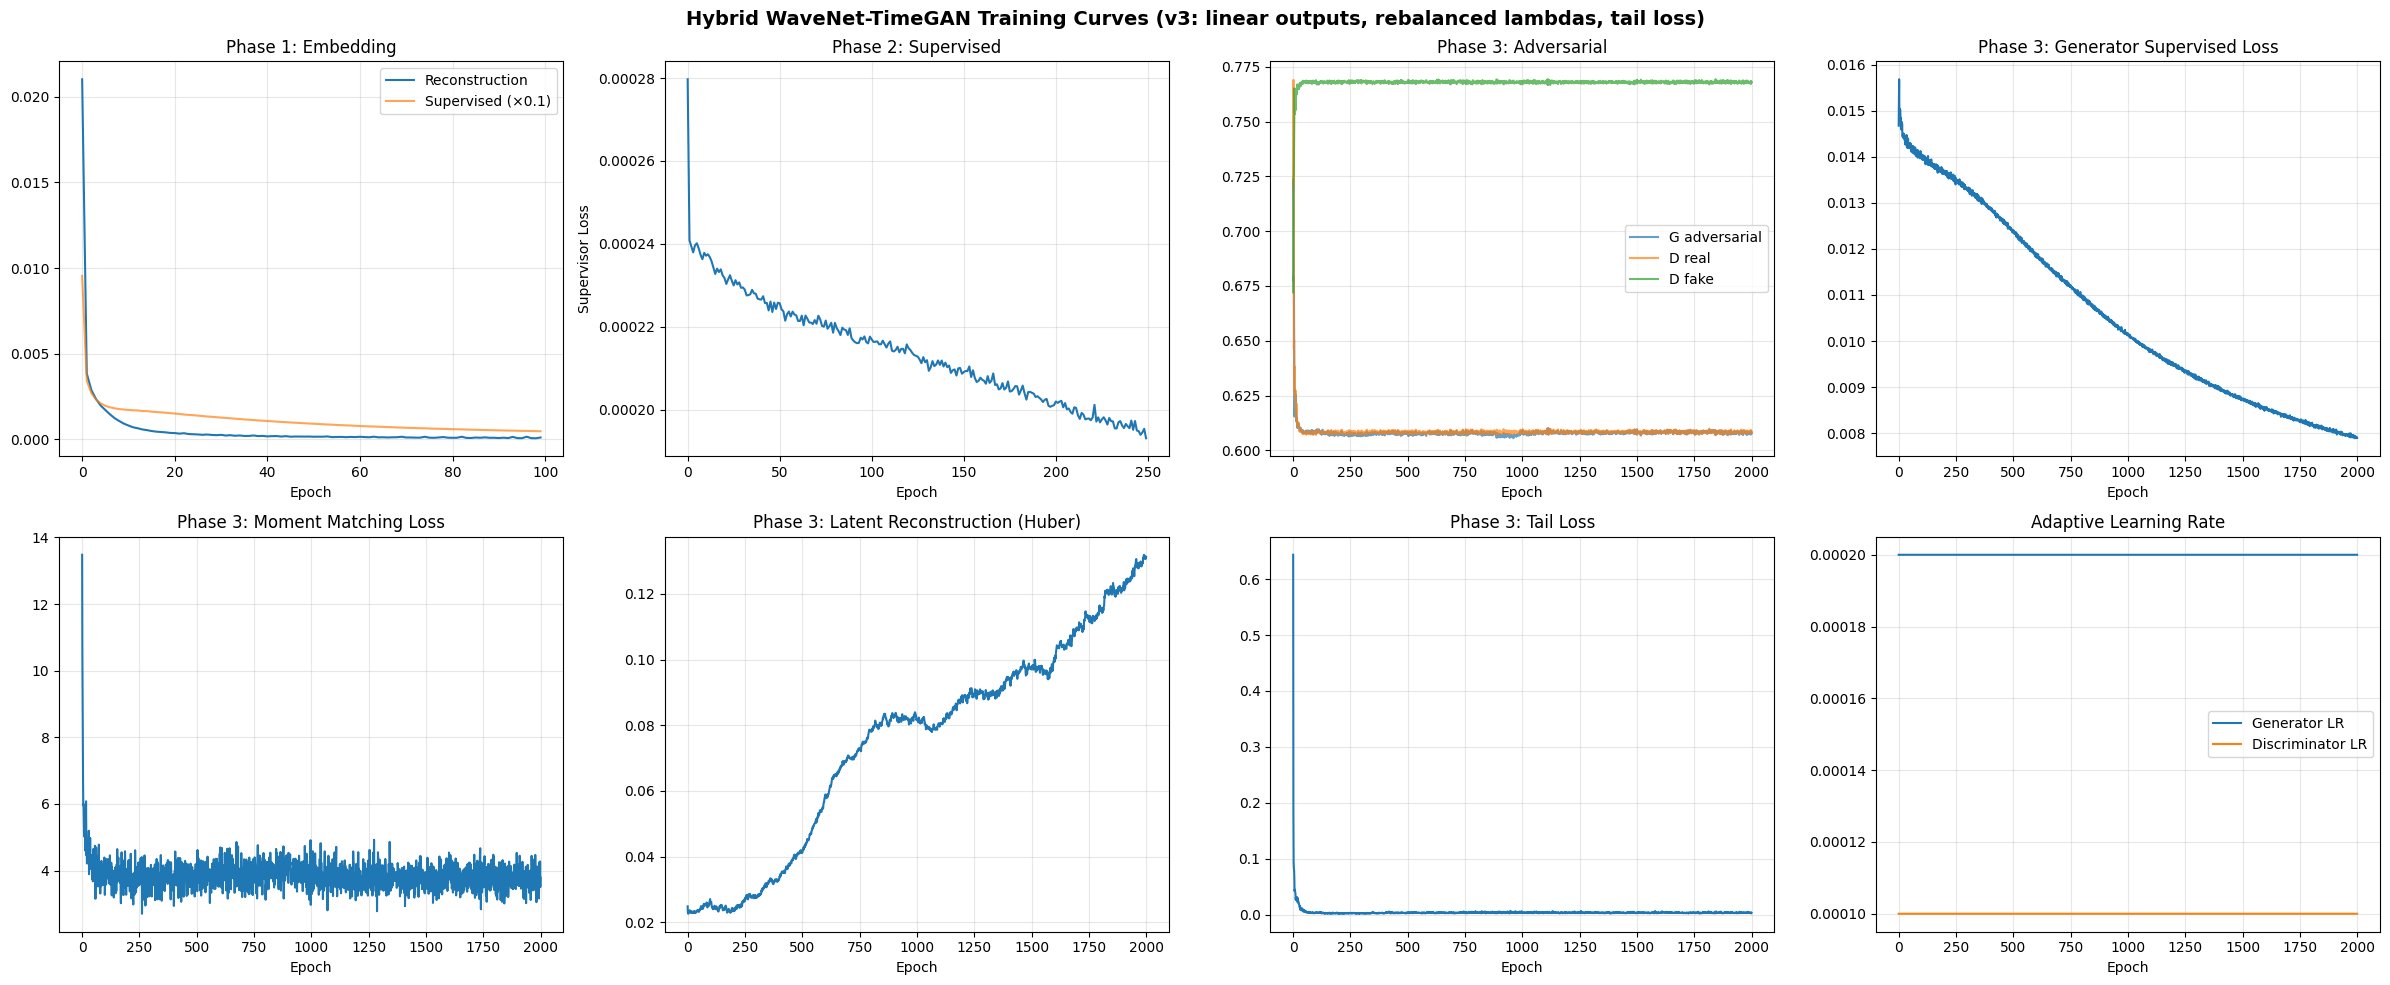

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

# Phase 1
axes[0, 0].plot(embedding_history['reconstruction'], label='Reconstruction')
axes[0, 0].plot(embedding_history['supervised'], label='Supervised (×0.1)', alpha=0.7)
axes[0, 0].set_title('Phase 1: Embedding')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Phase 2
axes[0, 1].plot(supervised_history)
axes[0, 1].set_title('Phase 2: Supervised')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Supervisor Loss')
axes[0, 1].grid(True, alpha=0.3)

# Phase 3 — Adversarial + LRs
axes[0, 2].plot(joint_history['g_adv'], label='G adversarial', alpha=0.7)
axes[0, 2].plot(joint_history['d_real'], label='D real', alpha=0.7)
axes[0, 2].plot(joint_history['d_fake'], label='D fake', alpha=0.7)
axes[0, 2].set_title('Phase 3: Adversarial')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Phase 3 — Supervised
axes[0, 3].plot(joint_history['g_sup'])
axes[0, 3].set_title('Phase 3: Generator Supervised Loss')
axes[0, 3].set_xlabel('Epoch')
axes[0, 3].grid(True, alpha=0.3)

# Phase 3 — Moment
axes[1, 0].plot(joint_history['g_moment'])
axes[1, 0].set_title('Phase 3: Moment Matching Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].grid(True, alpha=0.3)

# Phase 3 — Latent Reconstruction
axes[1, 1].plot(joint_history['g_recon_latent'])
axes[1, 1].set_title('Phase 3: Latent Reconstruction (Huber)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].grid(True, alpha=0.3)

# Phase 3 — Tail Loss
axes[1, 2].plot(joint_history['g_tail'])
axes[1, 2].set_title('Phase 3: Tail Loss')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].grid(True, alpha=0.3)

# LR evolution
axes[1, 3].plot(joint_history['lr_g'], label='Generator LR')
axes[1, 3].plot(joint_history['lr_d'], label='Discriminator LR')
axes[1, 3].set_title('Adaptive Learning Rate')
axes[1, 3].set_xlabel('Epoch')
axes[1, 3].legend()
axes[1, 3].grid(True, alpha=0.3)

plt.suptitle('Hybrid WaveNet-TimeGAN Training Curves (v3: linear outputs, rebalanced lambdas, tail loss)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Generate Synthetic Data

Generation pipeline: $Z \to \text{Generator} \to \hat{E} \to \text{Supervisor} \to \text{Recovery} \to \tilde{X}$

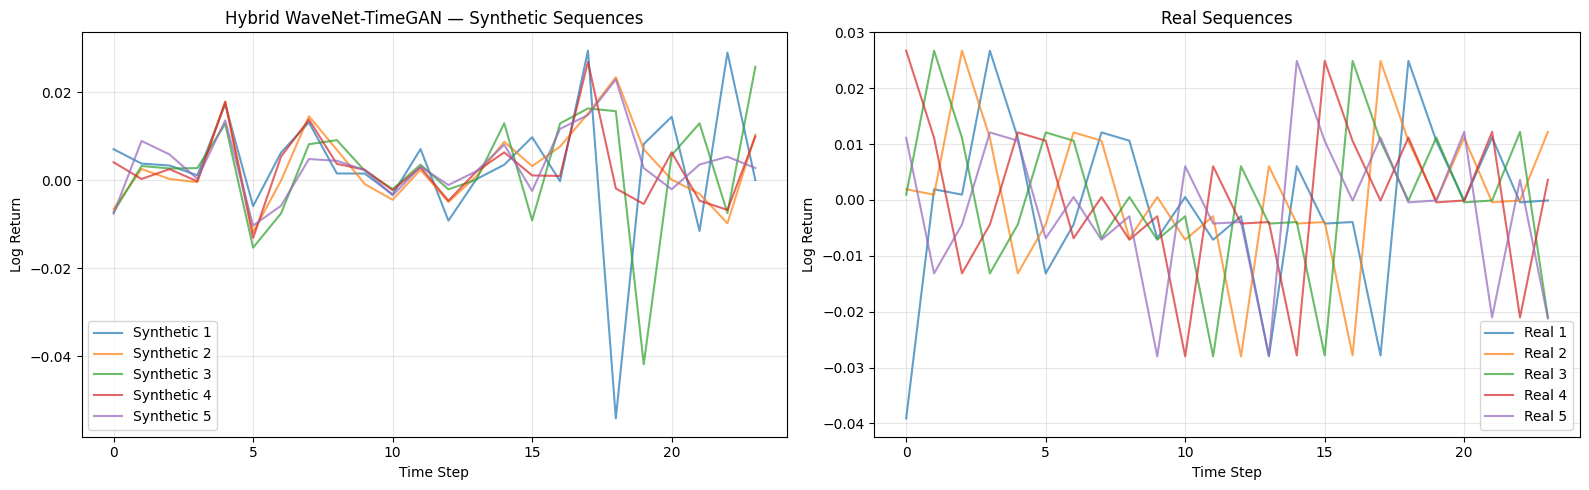

Synthetic — mean: 0.002471, std: 0.010696
Real      — mean: 0.000197, std: 0.012380


In [19]:
n_samples = 500

# Generate: noise → generator → supervisor (temporal smoothing) → recovery (to data space)
Z = tf.random.normal([n_samples, SEQUENCE_LENGTH, LATENT_DIM])
E_hat = generator(Z, training=False)
H_hat = supervisor(E_hat, training=False)
synthetic_sequences = recovery(H_hat, training=False).numpy()

# Rescale to original log-return space
synthetic_rescaled = scaler.inverse_transform(
    synthetic_sequences.reshape(-1, 1)
).reshape(n_samples, SEQUENCE_LENGTH)

real_rescaled = scaler.inverse_transform(
    sequences[:5].reshape(-1, 1)
).reshape(5, SEQUENCE_LENGTH)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i in range(5):
    axes[0].plot(synthetic_rescaled[i], alpha=0.7, label=f'Synthetic {i+1}')
axes[0].set_title('Hybrid WaveNet-TimeGAN — Synthetic Sequences')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Log Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i in range(5):
    axes[1].plot(real_rescaled[i], alpha=0.7, label=f'Real {i+1}')
axes[1].set_title('Real Sequences')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Log Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Synthetic — mean: {synthetic_rescaled.mean():.6f}, std: {synthetic_rescaled.std():.6f}")
print(f"Real      — mean: {log_returns.mean():.6f}, std: {log_returns.std():.6f}")

## 9. Save Models and Data

In [ ]:
os.makedirs('../models', exist_ok=True)

for m in [embedder, recovery, supervisor, generator, discriminator]:
    m.save(f'../models/hybrid_{m.name.lower()}_v9.keras')
    m.save_weights(f'../models/hybrid_{m.name.lower()}_v9.weights.h5')

np.save('../data/processed/synthetic_hybrid_wavenet_timegan_v9.npy', synthetic_sequences)
pd.DataFrame(
    synthetic_rescaled.flatten(), columns=['Synthetic_LogReturn']
).to_csv('../data/synthetic/hybrid_wavenet_timegan_synthetic_v9.csv', index=False)

print("All models and synthetic data saved.")

All models and synthetic data saved.


In [ ]:
# --- Diagnostic: extract training dynamics ---
import numpy as np

jh = joint_history
n = len(jh['g_adv'])
print(f"Joint training epochs: {n}")

# Final-window averages (last 100 epochs)
w = min(100, n)
keys = ['g_adv', 'd_real', 'd_fake', 'g_moment', 'g_sup', 'g_recon_latent', 'g_tail']
avgs = {k: np.mean(jh[k][-w:]) for k in keys}
for k, v in avgs.items():
    print(f"  {k:20s} = {v:.4f}")

# Loss budget — g_moment is already normalized by MOMENT_LOSS_SCALE in the training step
ga, gs, gm, gr, gt = avgs['g_adv'], avgs['g_sup'], avgs['g_moment'], avgs['g_recon_latent'], avgs['g_tail']
tot = ga + LAMBDA_SUPERVISED*gs + LAMBDA_RECONSTRUCTION*gm + LAMBDA_RECON_DATA*gr + LAMBDA_TAIL*gt
print(f"\nLoss budget (weighted, moment already normalized by {MOMENT_LOSS_SCALE}):")
print(f"  adv:    {ga/tot*100:5.1f}%  (raw {ga:.4f})")
print(f"  sup:    {LAMBDA_SUPERVISED*gs/tot*100:5.1f}%  (raw {gs:.4f} x {LAMBDA_SUPERVISED})")
print(f"  moment: {LAMBDA_RECONSTRUCTION*gm/tot*100:5.1f}%  (raw {gm:.4f} x {LAMBDA_RECONSTRUCTION})")
print(f"  recon:  {LAMBDA_RECON_DATA*gr/tot*100:5.1f}%  (raw {gr:.4f} x {LAMBDA_RECON_DATA})")
print(f"  tail:   {LAMBDA_TAIL*gt/tot*100:5.1f}%  (raw {gt:.4f} x {LAMBDA_TAIL})")

# LR adjustments
lr_g_arr = np.array(jh['lr_g'])
lr_changes = np.sum(np.abs(np.diff(lr_g_arr)) > 1e-8)
print(f"\nLR adjustments: {lr_changes}")

# Synthetic stats
syn = synthetic_sequences
print(f"\nSynthetic stats (scaled [0,1]):")
print(f"  mean={syn.mean():.4f}, std={syn.std():.4f}")
print(f"  min={syn.min():.4f}, max={syn.max():.4f}")
real = sequences
print(f"  std_ratio = {syn.std() / real.std():.3f}")

# Tail check
pct99 = np.percentile(syn, 99)
pct01 = np.percentile(syn, 1)
print(f"  p1={pct01:.4f}, p99={pct99:.4f}")
print(f"  >0.99: {(syn > 0.99).mean()*100:.2f}%")
print(f"  <0.01: {(syn < 0.01).mean()*100:.2f}%")

# Values outside [0,1]
print(f"  <0.0: {(syn < 0.0).mean()*100:.2f}%")
print(f"  >1.0: {(syn > 1.0).mean()*100:.2f}%")

NameError: name 'joint_history' is not defined